In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sea
import scipy.stats as stats
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

# um Warnungen zu ignorieren (auf eigene Gefahr!)
import warnings
warnings.filterwarnings("ignore")

### Multiple Lineare Regression

In [2]:
# wieder Pinguin-Daten laden
penguins = pd.read_excel('penguinsSmall.xlsx', index_col=0)

# selbes Vorgehen nur mit weiteren unabhängigen Variablen
cols = ['Flipper Length (mm)', 'Culmen Length (mm)', 'Culmen Depth (mm)'] # gewählte unabhängige Merkmale
target = 'Body Mass (g)' # abhängiges Merkmal
x_train, x_test, y_train, y_test = train_test_split(penguins[cols], penguins[target], train_size=0.8, random_state=1234)
var = sm.add_constant(x_train,prepend=True)
model = sm.OLS(y_train, var) 
res = model.fit()
pred = res.predict(sm.add_constant(x_test,prepend=True))
display(res.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          Body Mass (g)   R-squared:                       0.760
Model:                            OLS   Adj. R-squared:                  0.757
Method:                 Least Squares   F-statistic:                     277.7
Date:                Tue, 04 Nov 2025   Prob (F-statistic):           3.49e-81
Time:                        10:27:17   Log-Likelihood:                -1975.2
No. Observations:                 267   AIC:                             3958.
Df Residuals:                     263   BIC:                             3973.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const               -6258.0618    639.717     -9.783      0.000   -7517.681   -4998.442
Flipper Length (mm)    50.5204      2.879     17.550      0.000      44.852      56.188
Culmen Length (mm)      1.7339      6.078      0.285      0.776     -10.234      13.702
Culmen Depth (mm)      14.0471     15.591      0.901      0.368     -16.651      44.745
==============================================================================
Omnibus:                        4.256   Durbin-Watson:                   1.858
Prob(Omnibus):                  0.119   Jarque-Bera (JB):                4.028
Skew:                           0.297   Prob(JB):                        0.133
Kurtosis:                       3.095   Cond. No.                     5.44e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.44e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

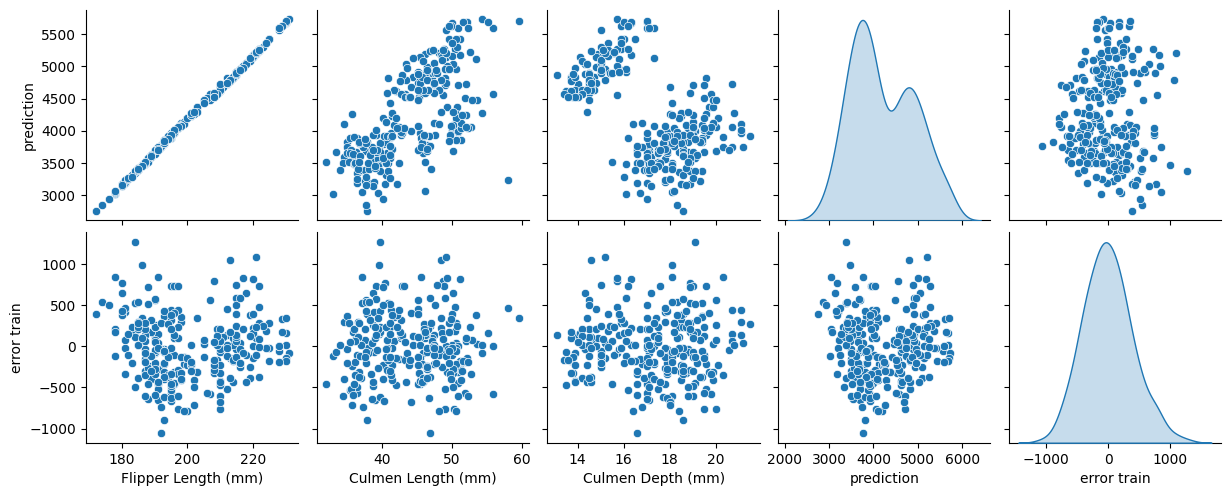

R-Quadrat Adj (Test): 0.7705



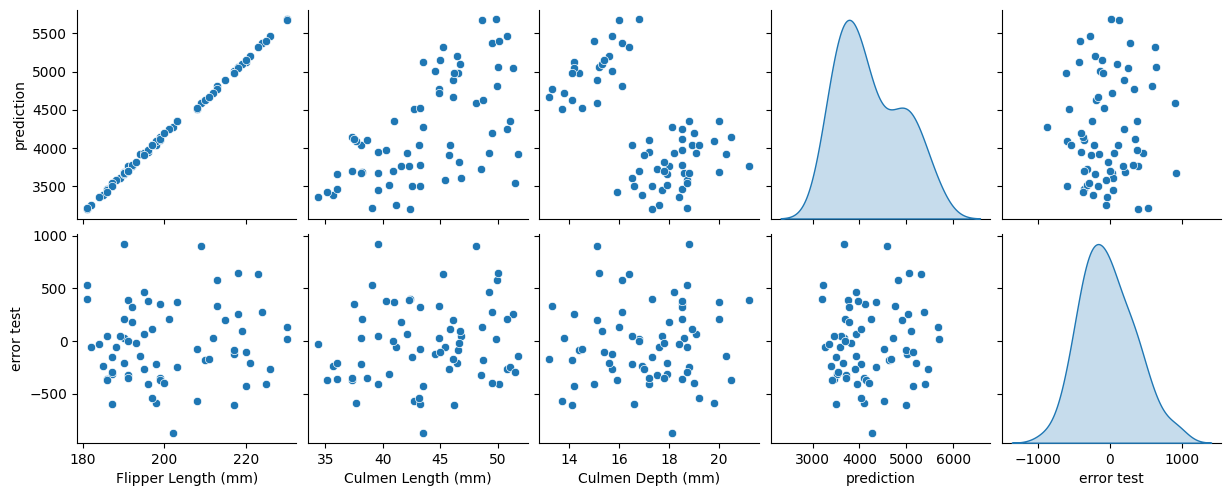

In [3]:
# grafische Darstellung
df = pd.DataFrame(x_train, columns=cols)
df['prediction'] = res.fittedvalues.values
df['error train'] = res.resid.values
sea.pairplot(data=df, diag_kind='kde', kind='scatter', y_vars={'prediction','error train'})
plt.show()

# da es keine spezifische methode für r-square-adjusted, entsprechend den Folien adaptiert
print('R-Quadrat Adj (Test): {0:.4f}\n'.format(1 - (y_test.shape[0] - 1)/(y_test.shape[0] - 1 - len(cols)) * (1-r2_score(y_test, pred))))
df = pd.DataFrame(x_test, columns=cols)
df['prediction'] = pred.values
df['error test'] = (y_test - pred).values
sea.pairplot(data=df, diag_kind='kde', kind='scatter', y_vars={'prediction','error test'})
plt.show()

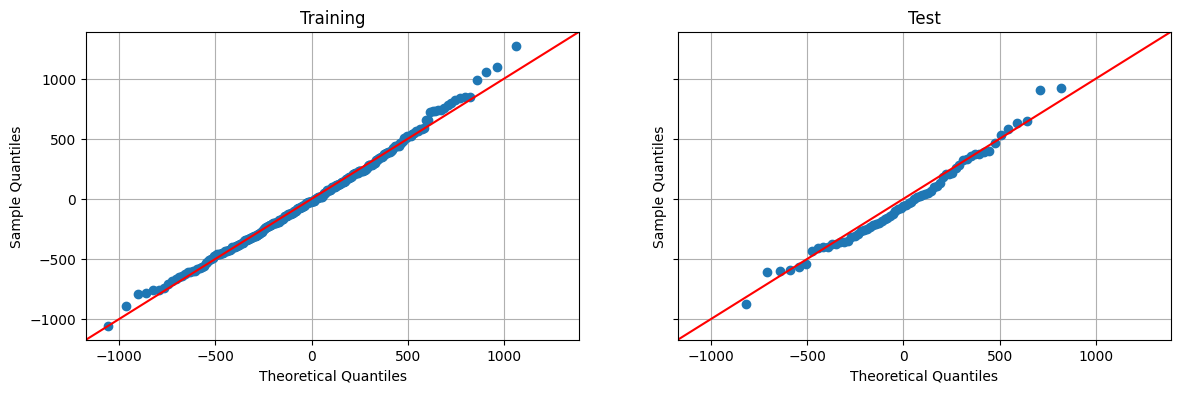

In [4]:
# mittels qq-plot
fig, axs = plt.subplots(1, 2, figsize=(14,4), sharex=True, sharey=True)
cax = axs[0]
rv = stats.norm(loc=0, scale=np.std(res.resid, ddof=2))
sm.qqplot(res.resid, rv, line='45', ax=cax)
cax.set_title('Training')
cax.grid()

cax = axs[1]
error = y_test - pred
rv = stats.norm(loc=0, scale=np.std(error, ddof=2))
sm.qqplot(error, rv, line='45', ax=cax)
cax.set_title('Test')
cax.grid()
plt.show()

#### Standardisierung der Features

In [5]:
# Bestimmung der Standardisierung basierend auf Trainingsdaten
scaler = StandardScaler()
scaler.fit(x_train)
x_train_st = scaler.transform(x_train) # gibt array zurück
x_train_st = pd.DataFrame(x_train_st, columns=x_train.columns, index=x_train.index)
display(x_train_st)

# Anwenden auf Testdaten
# benutzt selben Mean und Std wie bei Trainingsdaten!
x_test_st = pd.DataFrame(scaler.transform(x_test), columns=x_test.columns, index=x_test.index)

,Flipper Length (mm),Culmen Length (mm),Culmen Depth (mm)
128,-0.705710,-0.896429,-0.041708
166,-0.776706,0.332176,-0.041708
199,0.785215,0.884159,1.223762
7,-0.421724,-0.860818,1.223762
205,0.146247,1.186859,1.274381
...,...,...,...
210,0.075251,1.097829,0.818811
59,-0.492720,-1.145712,0.970668
302,0.785215,0.599265,-1.307179
217,-0.563717,0.990994,0.515099


In [6]:
# selbes Vorgehen nur mit standardisierten Features
var = sm.add_constant(x_train_st,prepend=True)
model = sm.OLS(y_train, var) 
res = model.fit()
pred = res.predict(sm.add_constant(x_test_st,prepend=True))
display(res.summary())
print('R-Quadrat Adj (Test): {0:.4f}\n'.format(1 - (y_test.shape[0] - 1)/(y_test.shape[0] - 1 - len(cols)) * (1-r2_score(y_test, pred))))

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          Body Mass (g)   R-squared:                       0.760
Model:                            OLS   Adj. R-squared:                  0.757
Method:                 Least Squares   F-statistic:                     277.7
Date:                Tue, 04 Nov 2025   Prob (F-statistic):           3.49e-81
Time:                        10:27:19   Log-Likelihood:                -1975.2
No. Observations:                 267   AIC:                             3958.
Df Residuals:                     263   BIC:                             3973.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                4211.2360     24.352    172.935      0.000    4163.287    4259.185
Flipper Length (mm)   711.5916     40.546     17.550      0.000     631.756     791.427
Culmen Length (mm)      9.7380     34.137      0.285      0.776     -57.478      76.954
Culmen Depth (mm)      27.7507     30.800      0.901      0.368     -32.896      88.397
==============================================================================
Omnibus:                        4.256   Durbin-Watson:                   1.858
Prob(Omnibus):                  0.119   Jarque-Bera (JB):                4.028
Skew:                           0.297   Prob(JB):                        0.133
Kurtosis:                       3.095   Cond. No.                         3.02
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

R-Quadrat Adj (Test): 0.7705



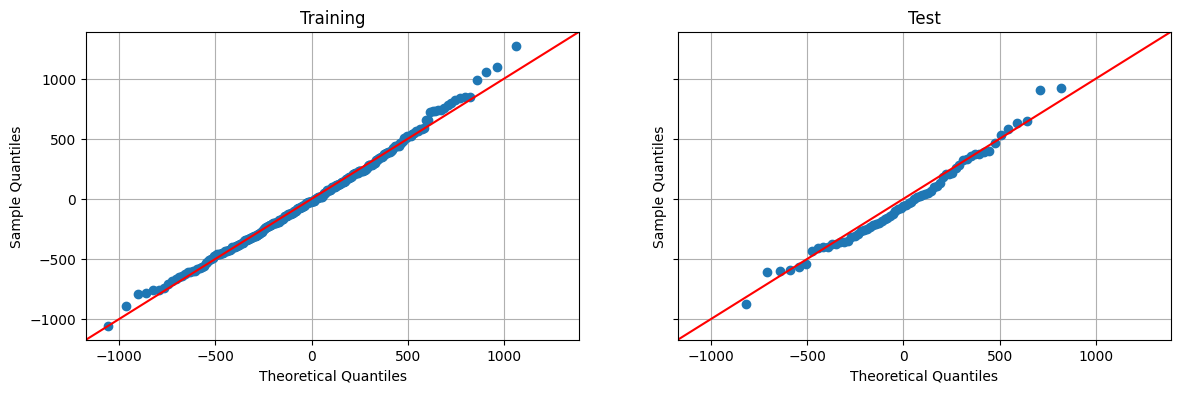

In [7]:
# grafische Darstellung
# mittels qq-plot
fig, axs = plt.subplots(1, 2, figsize=(14,4), sharex=True, sharey=True)
cax = axs[0]
rv = stats.norm(loc=0, scale=np.std(res.resid, ddof=2))
sm.qqplot(res.resid, rv, line='45', ax=cax)
cax.set_title('Training')
cax.grid()

cax = axs[1]
error = y_test - pred
rv = stats.norm(loc=0, scale=np.std(error, ddof=2))
sm.qqplot(error, rv, line='45', ax=cax)
cax.set_title('Test')
cax.grid()
plt.show()

#### Frage

Bestimme die Multiple Lineare Regression zur Vorhersage des Gewichtes für:
- nur männliche Pinguine
- nur für weibliche Pinguine

Welche Aussagen kannst du ableiten?

### Hinzufügen Kategorialer Merkmale und weiterer zusammengesetzter Merkmale

In [8]:
# Transformation eines nominalen Merkmals in ein numerisches Merkmal
# pandas.get_dummies: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html
tmp = pd.get_dummies(penguins['Sex'], dtype=int)
display(tmp.head(3))

# zusammenfügen von DataFrames mittels concat
penguins_new = pd.concat([penguins, tmp], axis=1)
display(penguins_new.head(5))

,FEMALE,MALE
0,0,1
1,1,0
2,1,0


,Individual ID,Species,Island,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,FEMALE,MALE
0,N1A1,Adelie,Torgersen,2007-11-11,39.1,18.7,181,3750,MALE,0,1
1,N1A2,Adelie,Torgersen,2007-11-11,39.5,17.4,186,3800,FEMALE,1,0
2,N2A1,Adelie,Torgersen,2007-11-16,40.3,18.0,195,3250,FEMALE,1,0
4,N3A1,Adelie,Torgersen,2007-11-16,36.7,19.3,193,3450,FEMALE,1,0
5,N3A2,Adelie,Torgersen,2007-11-16,39.3,20.6,190,3650,MALE,0,1


In [9]:
# multiple lineare regression
cols = ['Flipper Length (mm)', 'Culmen Depth (mm)', 'Culmen Length (mm)', 'FEMALE'] 
cols_metric = ['Flipper Length (mm)', 'Culmen Depth (mm)', 'Culmen Length (mm)']
target = 'Body Mass (g)'

# training / testing Aufteilung 
x_train, x_test, y_train, y_test = train_test_split(penguins_new[cols], penguins_new[target], train_size=0.8, random_state=1234)

# Standardisierung
scaler = StandardScaler()
scaler.fit(x_train[cols_metric])
x_train_st = pd.DataFrame(scaler.transform(x_train[cols_metric]), columns=cols_metric, index=x_train.index)
# hinzufügen der nominalen spalten
x_train_st.loc[:, 'FEMALE'] = x_train.loc[:, 'FEMALE']

# gleiches für testdaten
x_test_st = pd.DataFrame(scaler.transform(x_test[cols_metric]), columns=cols_metric, index=x_test.index)
x_test_st.loc[:, 'FEMALE'] = x_test.loc[:, 'FEMALE']

display(x_train_st.head(5))

,Flipper Length (mm),Culmen Depth (mm),Culmen Length (mm),FEMALE
128,-0.705710,-0.041708,-0.896429,1
166,-0.776706,-0.041708,0.332176,1
199,0.785215,1.223762,0.884159,0
7,-0.421724,1.223762,-0.860818,0
205,0.146247,1.274381,1.186859,0


In [10]:
# Multiple Lineare Regression
var = sm.add_constant(x_train_st,prepend=True)
model = sm.OLS(y_train, var) 
res = model.fit()
pred = res.predict(sm.add_constant(x_test_st,prepend=True))
display(res.summary())
print('R-Quadrat Adj (Test): {0:.4f}\n'.format(1 - (y_test.shape[0] - 1)/(y_test.shape[0] - 1 - len(cols)) * (1-r2_score(y_test, pred))))

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          Body Mass (g)   R-squared:                       0.820
Model:                            OLS   Adj. R-squared:                  0.817
Method:                 Least Squares   F-statistic:                     298.5
Date:                Tue, 04 Nov 2025   Prob (F-statistic):           2.87e-96
Time:                        10:27:20   Log-Likelihood:                -1936.7
No. Observations:                 267   AIC:                             3883.
Df Residuals:                     262   BIC:                             3901.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                4481.5520     35.812    125.142      0.000    4411.037    4552.067
Flipper Length (mm)   546.7148     39.351     13.893      0.000     469.230     624.199
Culmen Depth (mm)    -174.2538     34.366     -5.071      0.000    -241.922    -106.586
Culmen Length (mm)    -11.5887     29.705     -0.390      0.697     -70.079      46.902
FEMALE               -538.6148     57.615     -9.348      0.000    -652.063    -425.167
==============================================================================
Omnibus:                        1.927   Durbin-Watson:                   1.939
Prob(Omnibus):                  0.381   Jarque-Bera (JB):                1.721
Skew:                           0.085   Prob(JB):                        0.423
Kurtosis:                       2.645   Cond. No.                         4.87
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

R-Quadrat Adj (Test): 0.8246



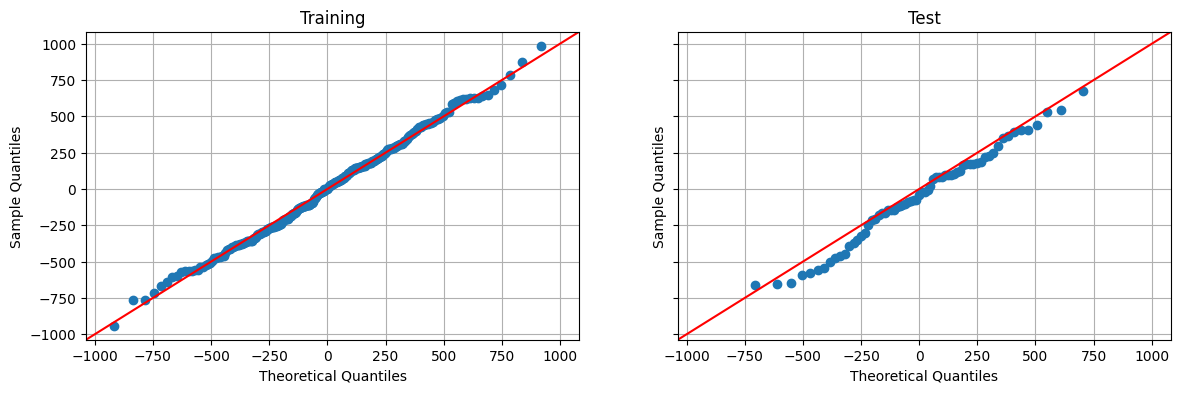

In [11]:
# grafische Darstellung
# mittels qq-plot
fig, axs = plt.subplots(1, 2, figsize=(14,4), sharex=True, sharey=True)
cax = axs[0]
rv = stats.norm(loc=0, scale=np.std(res.resid, ddof=2))
sm.qqplot(res.resid, rv, line='45', ax=cax)
cax.set_title('Training')
cax.grid()

cax = axs[1]
error = y_test - pred
rv = stats.norm(loc=0, scale=np.std(error, ddof=2))
sm.qqplot(error, rv, line='45', ax=cax)
cax.set_title('Test')
cax.grid()
plt.show()

In [12]:
# Verbesserung ohne Culmen Length?
cols = ['Flipper Length (mm)', 'Culmen Depth (mm)', 'FEMALE'] 
# Multiple Lineare Regression
var = sm.add_constant(x_train_st[cols],prepend=True)
model = sm.OLS(y_train, var) 
res = model.fit()
pred = res.predict(sm.add_constant(x_test_st[cols],prepend=True))
display(res.summary())
print('R-Quadrat Adj (Test): {0:.4f}\n'.format(1 - (y_test.shape[0] - 1)/(y_test.shape[0] - 1 - len(cols)) * (1-r2_score(y_test, pred))))

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          Body Mass (g)   R-squared:                       0.820
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     399.2
Date:                Tue, 04 Nov 2025   Prob (F-statistic):           1.42e-97
Time:                        10:27:20   Log-Likelihood:                -1936.8
No. Observations:                 267   AIC:                             3882.
Df Residuals:                     263   BIC:                             3896.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                4480.6856     35.685    125.562      0.000    4410.421    4550.950
Flipper Length (mm)   537.8867     32.142     16.735      0.000     474.599     601.175
Culmen Depth (mm)    -176.4975     33.826     -5.218      0.000    -243.102    -109.893
FEMALE               -536.8886     57.352     -9.361      0.000    -649.817    -423.960
==============================================================================
Omnibus:                        1.689   Durbin-Watson:                   1.935
Prob(Omnibus):                  0.430   Jarque-Bera (JB):                1.545
Skew:                           0.074   Prob(JB):                        0.462
Kurtosis:                       2.658   Cond. No.                         4.31
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

R-Quadrat Adj (Test): 0.8270



In [13]:
# bringen nicht-lineare Merkmale weitere Verbesserungen?
penguins_new['flipper_square'] = penguins_new['Flipper Length (mm)']**2
penguins_new['culmen_square'] = penguins_new['Culmen Depth (mm)']**2
penguins_new['flipper_culmen'] = penguins_new['Flipper Length (mm)']*penguins_new['Culmen Depth (mm)']
display(penguins_new.head(5))

,Individual ID,Species,Island,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,FEMALE,MALE,flipper_square,culmen_square,flipper_culmen
0,N1A1,Adelie,Torgersen,2007-11-11,39.1,18.7,181,3750,MALE,0,1,32761,349.69,3384.7
1,N1A2,Adelie,Torgersen,2007-11-11,39.5,17.4,186,3800,FEMALE,1,0,34596,302.76,3236.4
2,N2A1,Adelie,Torgersen,2007-11-16,40.3,18.0,195,3250,FEMALE,1,0,38025,324.00,3510.0
4,N3A1,Adelie,Torgersen,2007-11-16,36.7,19.3,193,3450,FEMALE,1,0,37249,372.49,3724.9
5,N3A2,Adelie,Torgersen,2007-11-16,39.3,20.6,190,3650,MALE,0,1,36100,424.36,3914.0


In [14]:
cols = ['Flipper Length (mm)', 'Culmen Depth (mm)', 'FEMALE', 'flipper_square', 'culmen_square', 'flipper_culmen'] 
cols_metric = ['Flipper Length (mm)', 'Culmen Depth (mm)', 'flipper_square', 'culmen_square', 'flipper_culmen']
target = 'Body Mass (g)'

# training / testing Aufteilung 
x_train, x_test, y_train, y_test = train_test_split(penguins_new[cols], penguins_new[target], train_size=0.8, random_state=1234)

# Standardisierung
scaler = StandardScaler()
scaler.fit(x_train[cols_metric])
x_train_st = pd.DataFrame(scaler.transform(x_train[cols_metric]), columns=cols_metric, index=x_train.index)
# hinzufügen der nominalen spalten
x_train_st.loc[:, 'FEMALE'] = x_train.loc[:, 'FEMALE']

# gleiches für testdaten
x_test_st = pd.DataFrame(scaler.transform(x_test[cols_metric]), columns=cols_metric, index=x_test.index)
x_test_st.loc[:, 'FEMALE'] = x_test.loc[:, 'FEMALE']

var = sm.add_constant(x_train_st,prepend=True)
model = sm.OLS(y_train, var) 
res = model.fit()
pred = res.predict(sm.add_constant(x_test_st,prepend=True))
display(res.summary())
print('R-Quadrat Adj (Test): {0:.4f}\n'.format(1 - (y_test.shape[0] - 1)/(y_test.shape[0] - 1 - len(cols)) * (1-r2_score(y_test, pred))))

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          Body Mass (g)   R-squared:                       0.852
Model:                            OLS   Adj. R-squared:                  0.849
Method:                 Least Squares   F-statistic:                     249.3
Date:                Tue, 04 Nov 2025   Prob (F-statistic):          9.12e-105
Time:                        10:27:20   Log-Likelihood:                -1910.7
No. Observations:                 267   AIC:                             3835.
Df Residuals:                     260   BIC:                             3861.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                4446.0951     33.083    134.392      0.000    4380.950    4511.240
Flipper Length (mm)   -57.2580    941.109     -0.061      0.952   -1910.423    1795.907
Culmen Depth (mm)    2291.1662    969.686      2.363      0.019     381.728    4200.604
flipper_square       2277.5852    710.273      3.207      0.002     878.965    3676.206
culmen_square         375.0941    443.830      0.845      0.399    -498.865    1249.054
flipper_culmen      -2315.6856    526.686     -4.397      0.000   -3352.799   -1278.572
FEMALE               -467.9655     53.627     -8.726      0.000    -573.563    -362.368
==============================================================================
Omnibus:                        4.196   Durbin-Watson:                   2.000
Prob(Omnibus):                  0.123   Jarque-Bera (JB):                4.252
Skew:                           0.284   Prob(JB):                        0.119
Kurtosis:                       2.755   Cond. No.                         145.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

R-Quadrat Adj (Test): 0.8028



In [15]:
cols = ['Flipper Length (mm)', 'Culmen Depth (mm)', 'FEMALE', 'flipper_square', 'flipper_culmen'] 
cols_metric = ['Flipper Length (mm)', 'Culmen Depth (mm)', 'flipper_square','flipper_culmen']
target = 'Body Mass (g)'

# training / testing Aufteilung 
x_train, x_test, y_train, y_test = train_test_split(penguins_new[cols], penguins_new[target], train_size=0.8, random_state=1234)

# Standardisierung
scaler = StandardScaler()
scaler.fit(x_train[cols_metric])
x_train_st = pd.DataFrame(scaler.transform(x_train[cols_metric]), columns=cols_metric, index=x_train.index)
# hinzufügen der nominalen spalten
x_train_st.loc[:, 'FEMALE'] = x_train.loc[:, 'FEMALE']

# gleiches für testdaten
x_test_st = pd.DataFrame(scaler.transform(x_test[cols_metric]), columns=cols_metric, index=x_test.index)
x_test_st.loc[:, 'FEMALE'] = x_test.loc[:, 'FEMALE']

var = sm.add_constant(x_train_st,prepend=True)
model = sm.OLS(y_train, var) 
res = model.fit()
pred = res.predict(sm.add_constant(x_test_st,prepend=True))
display(res.summary())
print('R-Quadrat Adj (Test): {0:.4f}\n'.format(1 - (y_test.shape[0] - 1)/(y_test.shape[0] - 1 - len(cols)) * (1-r2_score(y_test, pred))))

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          Body Mass (g)   R-squared:                       0.852
Model:                            OLS   Adj. R-squared:                  0.849
Method:                 Least Squares   F-statistic:                     299.4
Date:                Tue, 04 Nov 2025   Prob (F-statistic):          7.15e-106
Time:                        10:27:20   Log-Likelihood:                -1911.1
No. Observations:                 267   AIC:                             3834.
Df Residuals:                     261   BIC:                             3856.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                4444.1518     32.985    134.733      0.000    4379.201    4509.102
Flipper Length (mm)   452.3324    722.175      0.626      0.532    -969.699    1874.364
Culmen Depth (mm)    2980.2733    524.533      5.682      0.000    1947.418    4013.129
flipper_square       1958.3846    601.198      3.257      0.001     774.569    3142.200
flipper_culmen      -2571.9490    430.408     -5.976      0.000   -3419.462   -1724.436
FEMALE               -464.0935     53.401     -8.691      0.000    -569.246    -358.941
==============================================================================
Omnibus:                        4.105   Durbin-Watson:                   1.990
Prob(Omnibus):                  0.128   Jarque-Bera (JB):                4.137
Skew:                           0.276   Prob(JB):                        0.126
Kurtosis:                       2.740   Cond. No.                         82.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

R-Quadrat Adj (Test): 0.8081



#### Frage

Bestimme das bestmögliche lineare Modell zur Vorhersage des Gewichts unter Verwendung weiterer Merkmale und ihrer Kombinationen.

Das finale Modell soll nur statistisch signifikante Features enthalten (Ausnahme: kombinierte Merkmale).

Entferne Feature 'Flipper Length (mm)' (p=0.9631)
Entferne Feature 'Culmen Length (mm)' (p=0.6215)

Finale Featureliste:
['Culmen Depth (mm)', 'flipper_square', 'culmen_square', 'flipper_culmen', 'FEMALE']

Entferne Feature 'Culmen Length (mm)' (p=0.6215)

Finale Featureliste:
['Culmen Depth (mm)', 'flipper_square', 'culmen_square', 'flipper_culmen', 'FEMALE']


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          Body Mass (g)   R-squared:                       0.852
Model:                            OLS   Adj. R-squared:                  0.849
Method:                 Least Squares   F-statistic:                     300.3
Date:                Tue, 04 Nov 2025   Prob (F-statistic):          5.01e-106
Time:                        10:27:20   Log-Likelihood:                -1910.7
No. Observations:                 267   AIC:                             3833.
Df Residuals:                     261   BIC:                             3855.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              4446.0910     33.020    134.649      0.000    4381.072    4511.110
Culmen Depth (mm)  2337.0406    608.564      3.840      0.000    1138.721    3535.360
flipper_square     2237.4208    261.578      8.554      0.000    1722.348    2752.493
culmen_square       357.7931    340.116      1.052      0.294    -311.928    1027.514
flipper_culmen    -2339.2486    356.258     -6.566      0.000   -3040.754   -1637.743
FEMALE             -467.9575     53.524     -8.743      0.000    -573.351    -362.564
==============================================================================
Omnibus:                        4.169   Durbin-Watson:                   2.000
Prob(Omnibus):                  0.124   Jarque-Bera (JB):                4.221
Skew:                           0.282   Prob(JB):                        0.121
Kurtosis:                       2.754   Cond. No.                         68.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""


Test-R²: 0.8208
Test-MSE: 112797.2092


,feature,coef,pvalue
0,const,4446.091014,3.431517e-243
1,Culmen Depth (mm),2337.040621,1.543280e-04
2,flipper_square,2237.420757,1.028820e-15
3,culmen_square,357.793116,2.937847e-01
4,flipper_culmen,-2339.248607,2.774361e-10
5,FEMALE,-467.957468,2.833254e-16


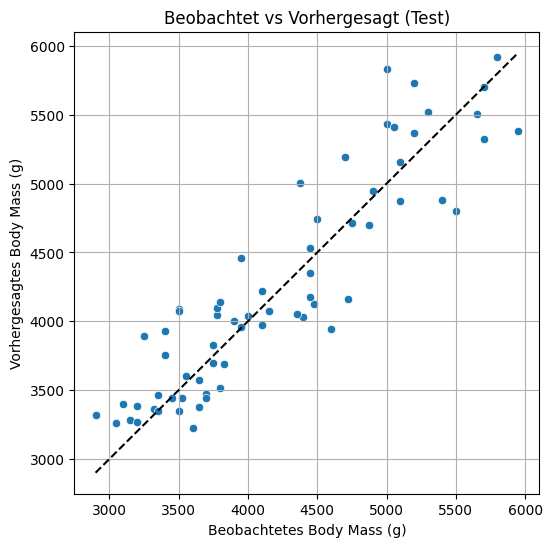

In [ ]:

df = penguins.copy()
# sichere Spaltennamen und NA-Filter
required = ['Body Mass (g)', 'Flipper Length (mm)', 'Culmen Length (mm)', 'Culmen Depth (mm)', 'Sex']
df = df.dropna(subset=required)

# Dummy für Sex (FEMALE als 1)
df['FEMALE'] = df['Sex'].astype(str).str.lower().str.strip().map({'female':1, 'male':0})
df['FEMALE'] = df['FEMALE'].fillna(0).astype(int)

# kombinierte / nicht-lineare Merkmale
df['flipper_square'] = df['Flipper Length (mm)']**2
df['culmen_square']  = df['Culmen Depth (mm)']**2
df['flipper_culmen'] = df['Flipper Length (mm)'] * df['Culmen Depth (mm)']

# Kandidaten-Featureliste (Hauptmerkmale + kombinierte Merkmale)
metric_cols = ['Flipper Length (mm)', 'Culmen Depth (mm)', 'Culmen Length (mm)','flipper_square','culmen_square','flipper_culmen']
all_features = metric_cols + ['FEMALE']
target = 'Body Mass (g)'

# Train/Test Split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(df[all_features], df[target], train_size=0.8, random_state=1234)

# Standardisierung numerischer Merkmale (nur die metrischen Spalten)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(x_train[metric_cols])
x_train_st = pd.DataFrame(scaler.transform(x_train[metric_cols]), columns=metric_cols, index=x_train.index)
x_test_st  = pd.DataFrame(scaler.transform(x_test[metric_cols]), columns=metric_cols, index=x_test.index)
# füge die nominale Spalte wieder hinzu
x_train_st['FEMALE'] = x_train['FEMALE'].values
x_test_st['FEMALE']  = x_test['FEMALE'].values

# Backward-Elimination: entferne nacheinander nicht-signifikante Haupteffekte (alpha=0.05)
import statsmodels.api as sm
alpha = 0.05
features = list(x_train_st.columns)
# Definiere kombinierte Merkmale, die wir NICHT automatisch entfernen wollen
combined_features = ['flipper_square','culmen_square','flipper_culmen']

while True:
    X = sm.add_constant(x_train_st[features], prepend=True)
    model = sm.OLS(y_train, X).fit()
    pvals = model.pvalues.drop('const')
    # Kandidaten nur die, die nicht in combined_features sind
    candidates = [f for f in pvals.index if f not in combined_features]
    if len(candidates) == 0:
        break
    # finde den größten p-Wert unter den Kandidaten
    max_p = pvals.loc[candidates].max()
    if max_p > alpha:
        remove = pvals.loc[candidates].idxmax()
        print(f"Entferne Feature '{remove}' (p={max_p:.4f})")
        features.remove(remove)
    else:
        break

# Endmodell
print('\nFinale Featureliste:')
print(features)
final_X = sm.add_constant(x_train_st[features], prepend=True)
final_model = sm.OLS(y_train, final_X).fit()
display(final_model.summary())

# Evaluation auf Testdaten
X_test_final = sm.add_constant(x_test_st[features], prepend=True)
y_pred = final_model.predict(X_test_final)
from sklearn.metrics import r2_score, mean_squared_error
print('\nTest-R²: {0:.4f}'.format(r2_score(y_test, y_pred)))
print('Test-MSE: {0:.4f}'.format(mean_squared_error(y_test, y_pred)))

# Optional: Zeige Koeffizienten (standardisierte Features interpretierbar)
coef_df = pd.DataFrame({'feature': ['const'] + features, 'coef': final_model.params.values, 'pvalue': final_model.pvalues.values})
display(coef_df)

# Kurze Visualisierung: beobachtet vs. vorhergesagt (Testdaten)
fig, ax = plt.subplots(1,1,figsize=(6,6))
sea.scatterplot(x=y_test, y=y_pred, ax=ax)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--', color='black')
ax.set_xlabel('Beobachtetes Body Mass (g)')
ax.set_ylabel('Vorhergesagtes Body Mass (g)')
ax.set_title('Beobachtet vs Vorhergesagt (Test)')
ax.grid(True)
plt.show()